# Very Fast Introduction to Statistical Classification and NN:
* Machine learning method based on supervised learning.
* Categories are predefined (unlike clustering in unsupervised learning).
* For two categories, the problem is known as binary classification. 
* Classifier assigns the most probable class to new observation, given the training set of examples.
* Bayes - density based classifiers vs. non density based classifiers.

## Curse of dimensionality

* When the dimensionality increases, the volume of the space increases so fast that the available data become sparse. 
* To obtain a statistically reliable result, the amount of data needed to support the result often grows exponentially with the dimensionality.
* In classification, an enormous amount of training data is required to ensure that there are several samples with each combination of values.
* The peaking paradox (Hughes phenomenon).
 
 ![Peaking](pics/Peaking.png)
 * Balancing feature size, training set size and the choice of the classifier is a basic problem in the design of classification problems.




## Overtraining 
* It happens if the complexity of the system we have chosen for training is too large for the given dataset.
* The trained system will adapt to the noise instead of to the class differences.
* The solution is either to enlarge the dataset, but, if not possible, to simplify the system.

## Binary vs. Multiple
Wiki: Classification can be thought of as two separate problems – binary classification and multiclass classification. In binary classification, a better understood task, only two classes are involved, whereas multiclass classification involves assigning an object to one of several classes.[9] Since many classification methods have been developed specifically for binary classification, multiclass classification often requires the combined use of multiple binary classifiers. 

## Linear classifier
* Linear Discriminant Analysis (or Fisher's linear discriminant) (LDA)—assumes Gaussian conditional density models
* Naive Bayes classifier with multinomial or multivariate Bernoulli event models.
* Logistic regression—maximum likelihood estimation of w → {\displaystyle {\vec {w}}} {\vec {w}} assuming that the observed training set was generated by a binomial model that depends on the output of the classifier.
* Perceptron—an algorithm that attempts to fix all errors encountered in the training set
* Support vector machine—an algorithm that maximizes the margin between the decision hyperplane and the examples in the training set.


Decision trees,Random forests

Neural networks

## Binary classification metrics
* Precision, Accuracy, Sensitivity, Specificity
 
![Precisionrecall](pics/Precisionrecall.png)

## Precision, recall and ROC

* true positive  (TP)
* true negative  (TN)
* false positive (FP)
* false negative (FN)

* sensitivity, recall, hit rate, or true positive rate (TPR)
$$  {TPR} ={\frac { {TP} }{ {P} }}={\frac { {TP} }{ {TP} + {FN} }}=1- {FNR} $$

* specificity, selectivity or true negative rate (TNR)
$$ {TNR} ={\frac { {TN} }{ {N} }}={\frac { {TN} }{ {TN} + {FP} }}=1- {FPR} $$

* precision or positive predictive value (PPV)
$${  {PPV} ={\frac { {TP} }{ {TP} + {FP} }}=1- {FDR} }$$

* negative predictive value (NPV)
$${  {NPV} ={\frac { {TN} }{ {TN} + {FN} }}=1- {FOR} } $$

* false positive rate (FPR) (alpha - type I error)
$$ {  {FPR} ={\frac { {FP} }{ {N} }}={\frac { {FP} }{ {FP} + {TN} }}=1- {TNR} } $$

* false negative rate (FNR) (beta - type II error)
$$ {  {FNR} ={\frac { {FN} }{ {P} }}={\frac { {FN} }{ {FN} + {TP} }}=1- {TPR} }$$

* acuracy (ACC)
$$ {  {ACC} ={\frac { {TP} + {TN} }{ {P} + {N} }}={\frac { {TP} + {TN} }{ {TP} + {TN} + {FP} + {FN} }}} $$

* F1 score is the harmonic mean of precision and sensitivity
$${  {F} _{1}=2\cdot {\frac { {PPV} \cdot  {TPR} }{ {PPV} + {TPR} }}={\frac {2 {TP} }{2 {TP} + {FP} + {FN} }}} $$

![ROC_curves](pics/ROC_curves.png)

The generalization of Recall and Precision to multiclass problems is to sum over rows (columns) of the confusion matrix. 

## Cross Validation
covered in the last lesson, 10 can be replaced by k
* 10-fold cross-validation, very popular and has become a standard procedure in many papers and works.
* 10 times 10-fold cross-validation, useful for comparing classifiers as the 10 repeats shrink the standard deviations in the means of the estimated classifier errors.
* 10 times 2-fold cross-validation helps compute the significance of differences in classification error means.
* Leave-one-out (LOO) cross-validation. In this case the number of folds is equal to the number of objects in the design set. 

## Grid Search
* Help us to find the "best" hyperparameters of given method to optimize loss function or evaluation metrics.
* Use pipelines and run the process as much as possible. Depends on time and resources.

Back to code ...




In [1]:
import numpy as np
import pandas as pd
import os
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt


import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats


In [2]:
# load our dataset
data = 'data/attrition.csv'
df = pd.read_csv(data)

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.describe(include=['object'])

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [5]:
df = df.sample(frac=1, random_state=42)
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
# let's drop EmployeeID
df.drop(['EmployeeNumber', 'EmployeeCount','StandardHours','Over18'], axis=1, inplace=True)

In [7]:
# select response variable and features
target_col_name = 'Attrition'
num_feature_cols = [
        'Age', 'DailyRate','DistanceFromHome', 'Education',
        'HourlyRate', 'EnvironmentSatisfaction', 'JobInvolvement','JobLevel',
        'JobSatisfaction', 'NumCompaniesWorked', 'PercentSalaryHike',
        'RelationshipSatisfaction', 'StockOptionLevel', 'PerformanceRating',
        'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
        'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
        'YearsWithCurrManager', 'MonthlyRate']
cat_feature_cols = [x for x in df.columns if x not in num_feature_cols and x not in [target_col_name]]

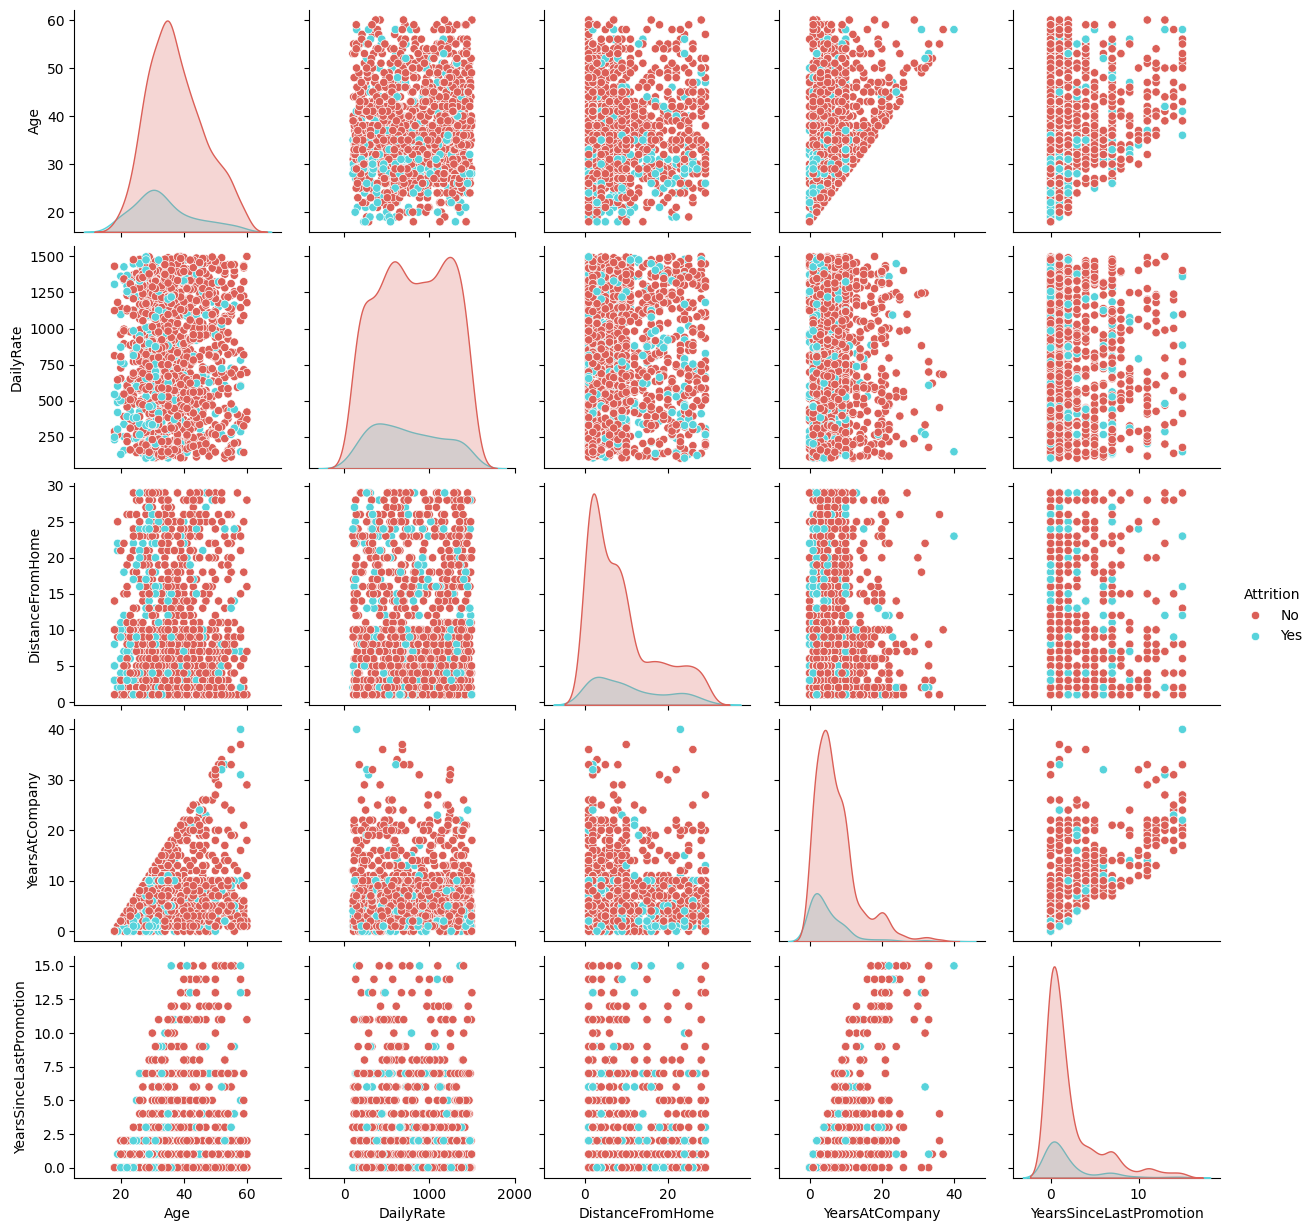

In [8]:
sns.pairplot(df, hue="Attrition",vars=['Age','DailyRate','DistanceFromHome','YearsAtCompany','YearsSinceLastPromotion'],palette="hls")

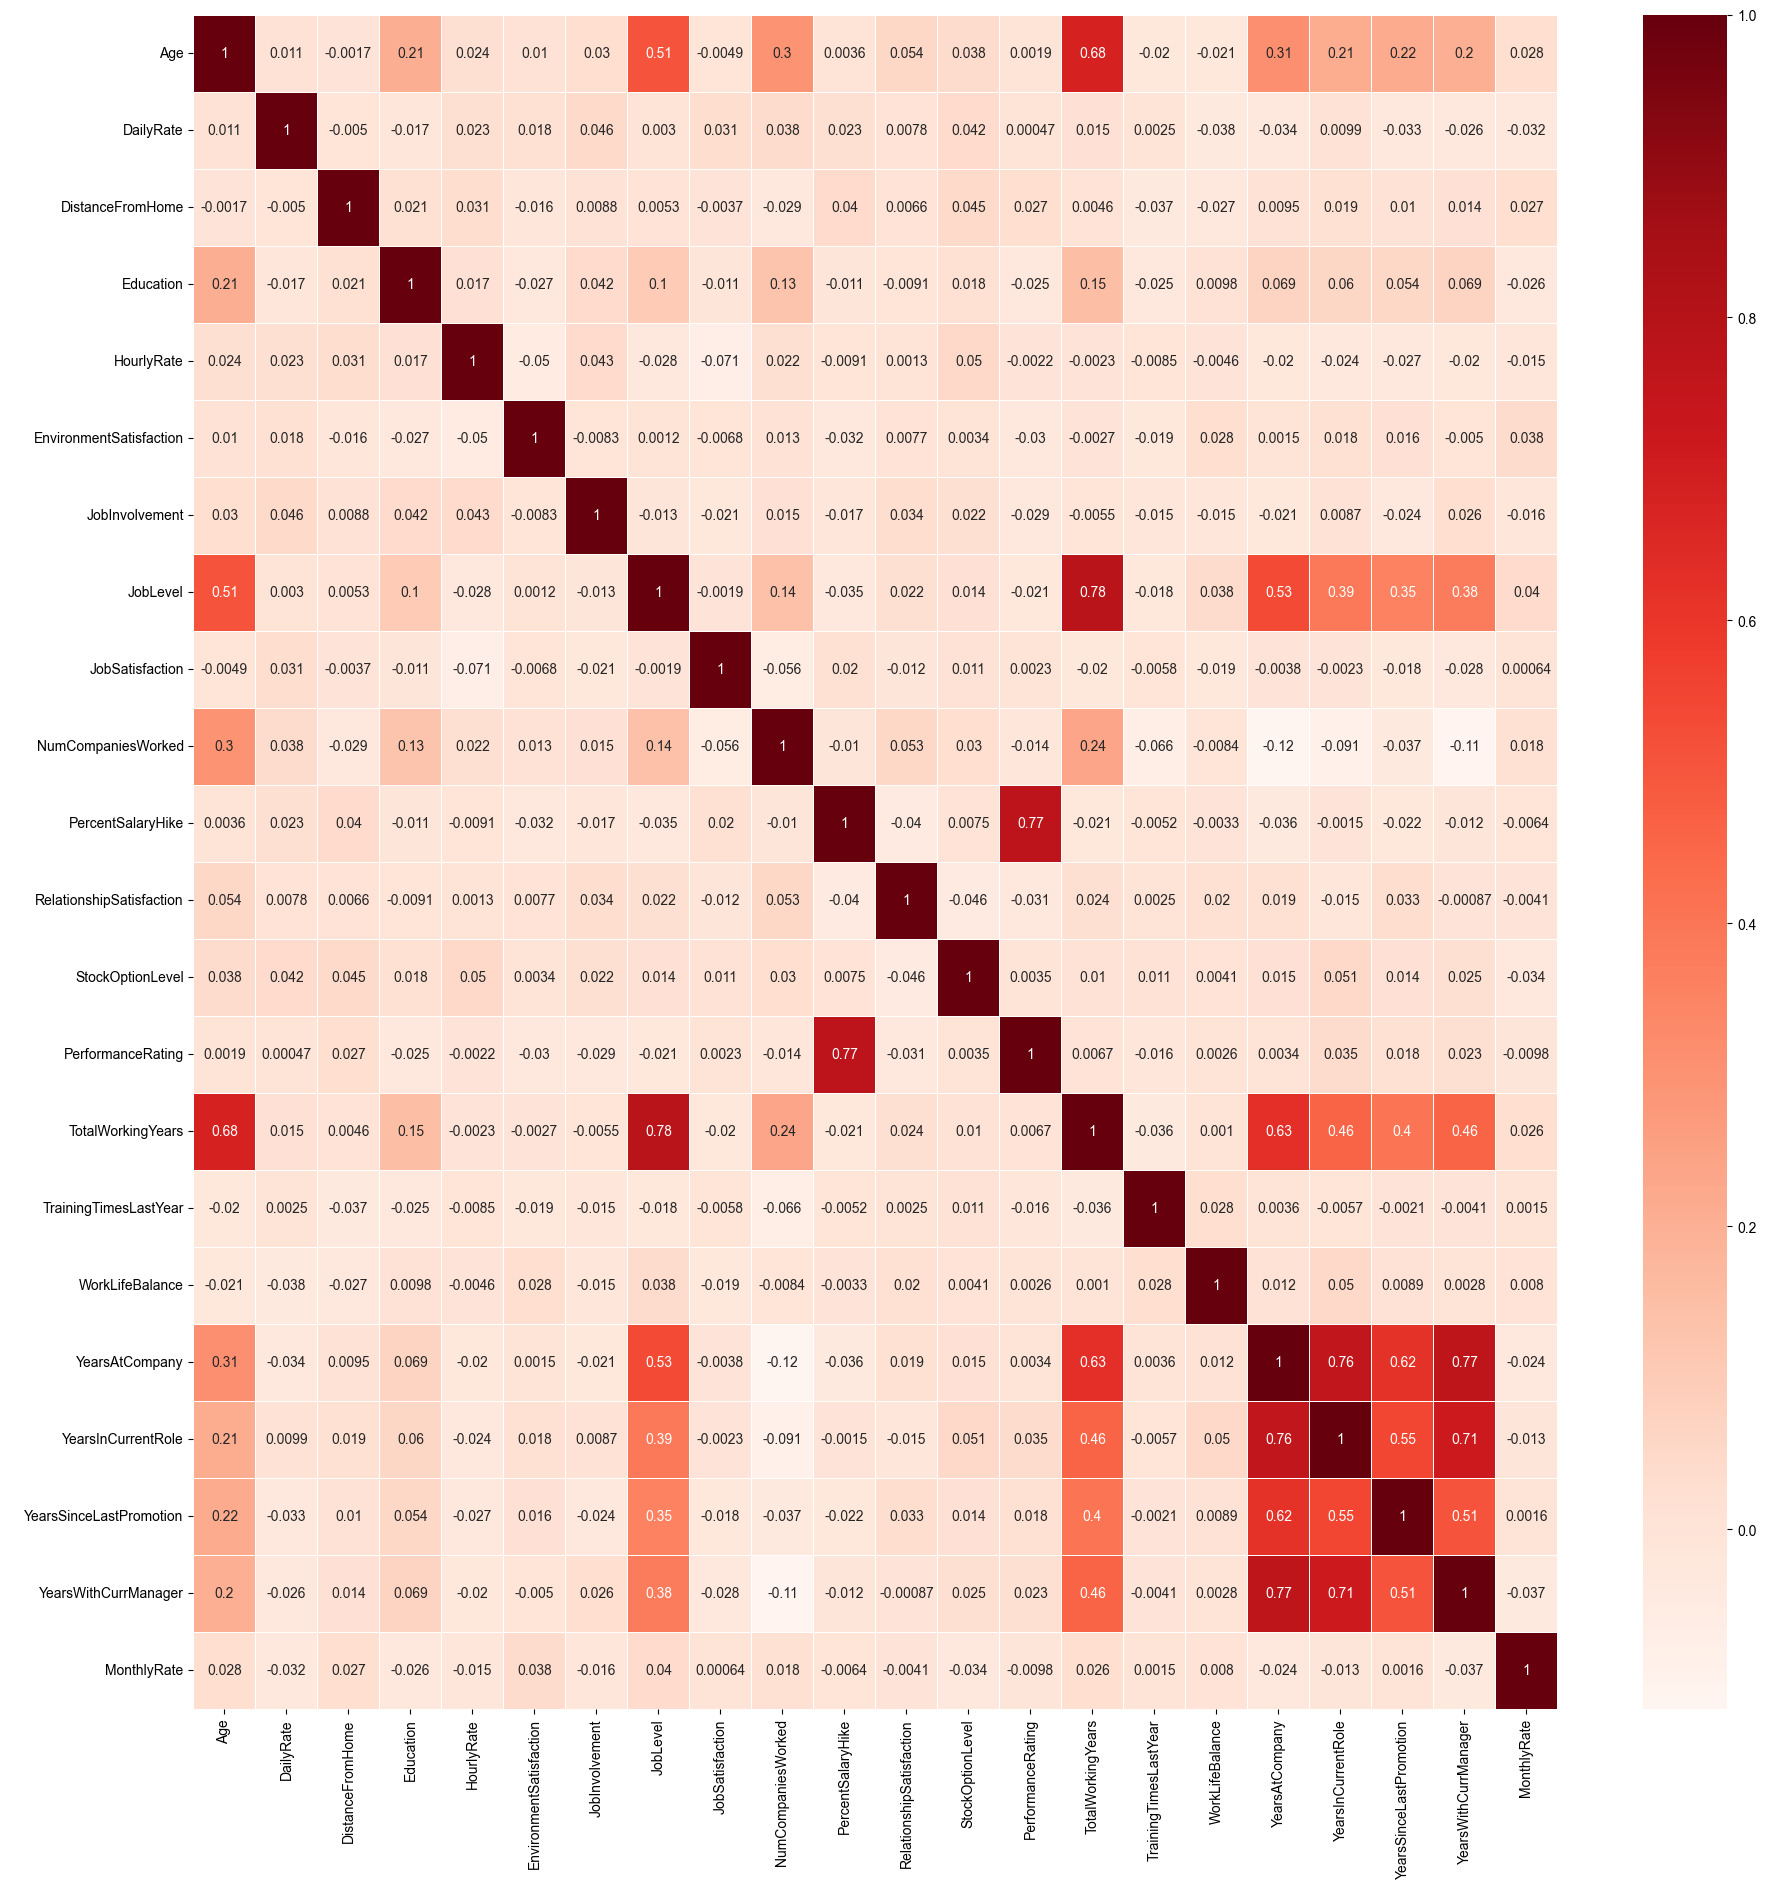

In [9]:
plt.figure(figsize=(22, 22))
sns.heatmap(df[num_feature_cols].corr(), cmap='Reds', linewidth=.5, annot=True)
sns.set(font_scale=1)
plt.show()

In [10]:
# cast numerical columns as float
for col in num_feature_cols:
    df[col] = df[col].astype(float)

In [11]:
#df_target = np.ravel(df[[target_col_name]])
df_target = df[target_col_name].values  # Convert target column to NumPy array

df_features = df[num_feature_cols]
df_target

array(['No', 'No', 'Yes', ..., 'Yes', 'No', 'No'],
      shape=(1470,), dtype=object)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(df_features, df_target, test_size=0.2, random_state=42)

In [13]:
# Use standard version of logistic regression
logmodel = LogisticRegression(max_iter=1000)  # Increase max_iter from default 100 to 1000
logmodel.fit(X_train, y_train)

c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
from sklearn.preprocessing import StandardScaler

# Correcting the target selection
df_target = df[target_col_name].values  # Convert target column to NumPy array

# Selecting feature columns
df_features = df[num_feature_cols]

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(df_features, df_target, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training the logistic regression model
logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [15]:
y_pred=logmodel.predict(X_test)

# Specify the target names as a keyword argument
target_names = ['No', 'Yes']
print(classification_report(y_test, y_pred, target_names=target_names))

# Note that in binary classification, 
# recall of the positive class is also known as “sensitivity”;
# recall of the negative class is “specificity”.

              precision    recall  f1-score   support

          No       0.87      0.14      0.23       244
         Yes       0.18      0.90      0.29        50

    accuracy                           0.27       294
   macro avg       0.52      0.52      0.26       294
weighted avg       0.75      0.27      0.24       294



c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Text(0.5, 1, 'Confusion matrix')

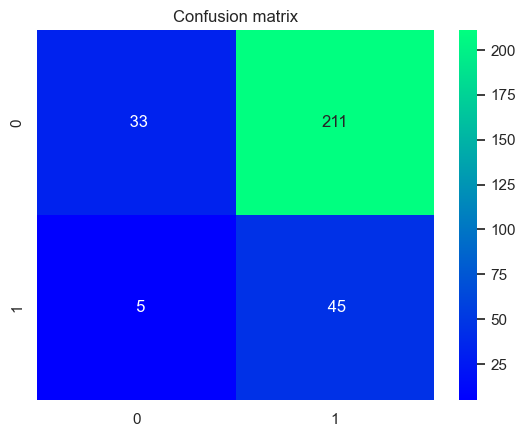

In [16]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='3.0f',cmap="winter")
plt.title('Confusion matrix', y=1, size=12)

In [17]:
confusion_matrix(y_test, y_pred)


array([[ 33, 211],
       [  5,  45]])

In [18]:
#Example of R style analysis :-D

# Fit the GLM model
mod1 = smf.glm(formula='Attrition ~ Age * DailyRate + DistanceFromHome + Education + HourlyRate', 
               data=df, 
               family=sm.families.Binomial()).fit()

# Generate predicted probabilities on X_test
# Note: X_test must have the same columns as specified in the formula
y_pred_prob = mod1.predict(X_test)

# Convert probabilities to binary predictions (using a threshold of 0.5)
y_pred = np.where(y_pred_prob > 0.85, 1, 0)

# Convert y_true from 'No'/'Yes' to 0/1 for comparison
y_true = df['Attrition'].map({'No': 0, 'Yes': 1}).values[:len(X_test)]  # Match the length with X_test

# Generate and print the classification report
target_names = ['No', 'Yes']  # Use these for label interpretation
print(classification_report(y_true, y_pred, target_names=target_names))



              precision    recall  f1-score   support

          No       0.88      0.51      0.65       255
         Yes       0.14      0.54      0.23        39

    accuracy                           0.52       294
   macro avg       0.51      0.53      0.44       294
weighted avg       0.78      0.52      0.59       294



Text(0.5, 1, 'Confusion matrix')

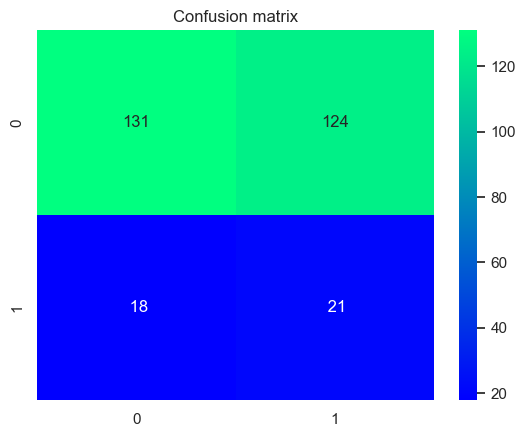

In [19]:
sns.heatmap(confusion_matrix(y_true,y_pred),annot=True,fmt='3.0f',cmap="winter")
plt.title('Confusion matrix', y=1, size=12)

In [20]:
mod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Generalized Linear Model Regression Results                          
===============================================================================================
Dep. Variable:     ['Attrition[No]', 'Attrition[Yes]']   No. Observations:                 1470
Model:                                             GLM   Df Residuals:                     1463
Model Family:                                 Binomial   Df Model:                            6
Link Function:                                   Logit   Scale:                          1.0000
Method:                                           IRLS   Log-Likelihood:                -622.73
Date:                                 Thu, 06 Nov 2025   Deviance:                       1245.5
Time:                                         13:42:24   Pearson chi2:                 1.53e+03
No. Iterations:                                      5   Pseudo R-squ. (CS):            0.03549
Covariance Type:                             nonrobust                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.4113      0.719     -0.572      0.567      -1.821       0.998
Age                  0.0571      0.019      3.034      0.002       0.020       0.094
DailyRate            0.0006      0.001      0.735      0.462      -0.001       0.002
Age:DailyRate    -5.273e-06   2.16e-05     -0.244      0.807   -4.76e-05    3.71e-05
DistanceFromHome    -0.0258      0.009     -3.028      0.002      -0.043      -0.009
Education           -0.0126      0.072     -0.175      0.861      -0.154       0.129
HourlyRate           0.0004      0.004      0.116      0.907      -0.007       0.007
====================================================================================
"""

In [21]:
#Creating K fold Cross-validation 
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(logmodel, # model
                         X_train, # Feature matrix
                         y_train, # Target vector
                         cv=kf, # Cross-validation technique
                         scoring="accuracy", # Loss function
                         n_jobs=-1) # Use all CPU scores
print('10 fold CV accuracy: %.3f +/- %.3f' % (np.mean(scores), np.std(scores)))


10 fold CV accuracy: 0.842 +/- 0.036


In [22]:
# Support Vector Machines

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Support Vector Machine model
svc = SVC()
svc.fit(X_train_scaled, y_train)

# Predict on the scaled test data
y_pred = svc.predict(X_test_scaled)

# Define target names if not defined earlier
target_names = ['No', 'Yes'] 

# Print classification report
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

          No       0.83      1.00      0.91       244
         Yes       1.00      0.02      0.04        50

    accuracy                           0.83       294
   macro avg       0.92      0.51      0.47       294
weighted avg       0.86      0.83      0.76       294



Text(0.5, 1, 'Confusion matrix')

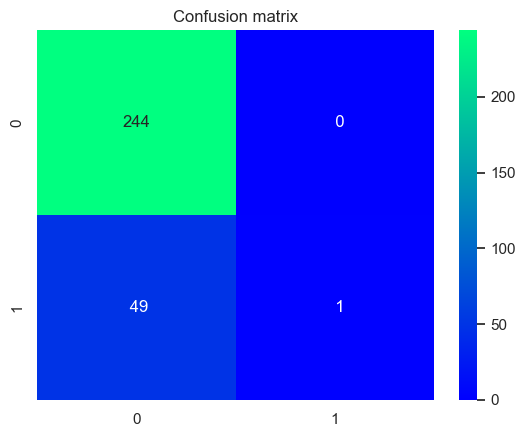

In [23]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='3.0f',cmap="winter")
plt.title('Confusion matrix', y=1, size=12)

# Neural Networks
* [ ] https://karpathy.github.io/neuralnets/
* [ ] https://playground.tensorflow.org/

### XOR using NN
Let's predict Exclusive OR using NN

```
+---+---+---------+
| A | B | A XOR B |
+---+---+---------+
| 1 | 1 | 0       |
+---+---+---------+
| 1 | 0 | 1       |
+---+---+---------+
| 0 | 1 | 1       |
+---+---+---------+
| 0 | 0 | 0       |
+---+---+---------+
```

It's a binary classification problem, and a supervised one. Our task is to create a neural network that will predict the values of one logical function given the inputs.

Let's assume the simple shallow architecture with hidden layer
![NNet](pics/NNEt.png)

* `X1,X2` = data input
* `N1,N2,N3` = neurons
* `B1,B2` = bias
* `W..` = weights
* `b..` = bias weights
* `Y` = output

Bias node is "always on" -- in NN has the role of the intercept and it's providing a way to get non-zero output on zero inputs. Without bias, the activation of features = 0 would be always zero. When using sigmoid function for example, the output of the (0,0) would be 0.5. 

We'll assume sigmoid neurons:
* they accept real values as inputs
* the value of activation is a dot product of weights and inputs (+ bias), i.e. `W*out_{prev} + b`
* output is a sigmoid function of its activation value

In [24]:
import numpy as np
import matplotlib.pyplot as plt

In [25]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [26]:
def sigmoid_derivative(x):
    """
    x is assumed to be sigmoid function!
    """
    return x*(1-x)

In [27]:
x = np.arange(-10,10,0.01)

In [28]:
x

array([-10.  ,  -9.99,  -9.98, ...,   9.97,   9.98,   9.99], shape=(2000,))

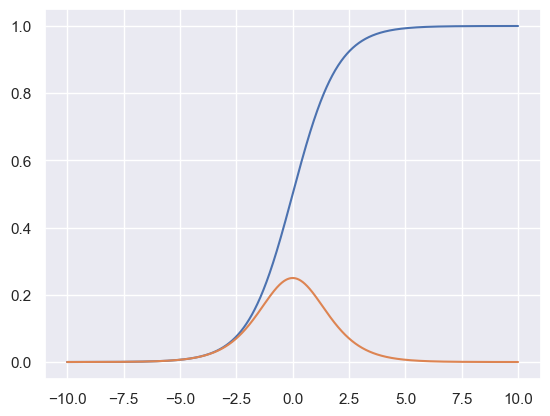

In [29]:
plt.plot(x, sigmoid(x), x, sigmoid_derivative(sigmoid(x)))
plt.show()

#### Learning
Information is stored in connections between the neurons -- the weights. NN learns by updating its weights according to a learning algorithm that helps it converge to the expected output.

* Initialize the weights and biases randomly.
* Iterate over the data
    * Compute the predicted output
    * Compute the loss (distance from the data)
    * `W(new) = W(old) — α ∆W`
    * `b(new) = b(old) — α ∆b`
* Repeat until the error is minimal

Update step is assumed in the direction of gradient descent.

There are two parts to the learning algorithm
* Forward pass (computation of the predicted output)
* Backward pass, aka backpropagation (change of the weights)

#### Data
Let's create our learning dataset

In [30]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([[0],[1],[1],[0]])

In [31]:
X

array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1]])

In [32]:
Y

array([[0],
       [1],
       [1],
       [0]])

#### Initialization of the weights and biases
Let's sample normal distribution

In [33]:
def init_params(n_X,n_H,n_Y):
    """
    n_X ... number of input layer neurons
    n_H ... number of hidden layer neurons
    n_Y ... number of output layer neurons
    """
    W1 = np.random.randn(n_X, n_H)
    b1 = np.zeros((1, n_H))
    W2 = np.random.randn(n_H, n_Y)
    b2 = np.zeros((1, n_Y))
    
    return W1,b1,W2,b2

In [34]:
(W1, b1, W2, b2) = init_params(2, 2, 1)
print("Initial hidden weights: ",end='')
print(*W1)
print("Initial hidden biases: ",end='')
print(*b1)
print("Initial output weights: ",end='')
print(*W2)
print("Initial output biases: ",end='')
print(*b2)

Initial hidden weights: [ 1.32102126 -2.15362102] [ 1.18613061 -0.7506544 ]
Initial hidden biases: [0. 0.]
Initial output weights: [-1.09359367] [-0.2036367]
Initial output biases: [0.]


In [35]:
epochs = 10000
lr = 0.1

#### Forward propagation
Computing the predicted values

In [36]:
def forward_prop(X,W1,b1,W2,b2):
    hidden_layer_activation = np.dot(X,W1) + b1
    hidden_layer_output = sigmoid(hidden_layer_activation)

    output_layer_activation = np.dot(hidden_layer_output,W2) + b2 
    Y_hat = sigmoid(output_layer_activation)
    
    return hidden_layer_output, Y_hat

#### Error (loss) function
Let's use mean squared error. Typically used rather for regression problems, but we'll ignore that for now.

$E = \frac{1}{2}(Y - Y_{hat})^2$

We're going to need it's derivative (w.r.t. $Y_{hat}$)

$\frac{\partial E}{\partial Y_{hat}} = -(Y - Y_{hat})$

In [37]:
def loss_function(Y,Y_hat):
    loss = 1/2*np.sum(np.power(Y-Y_hat,2))
    
    return loss

In [38]:
def loss_derivative(Y,Y_hat):
    d_loss = -(Y - Y_hat)
    
    return d_loss

#### Backpropagation
Goal of the backpropagation is to change the weights in order to minimize the error/loss. Since the outcome is a function of activation and further activation is a function of weights, so we want to know

$\frac{\partial E}{\partial w21} = \frac{\partial E}{\partial Y_{hat}} * \frac{\partial Y_{hat}}{\partial net_{N3}} * \frac{\partial net_{N3}}{\partial w21}$

We are interested in the derivative of the error with respect to a particular weight ($w21$), which represents the connection between a hidden layer neuron ($N1$) and an output layer neuron ($N3$).

We already know the derivative of the error with respect to the prediction.
$\frac{\partial E}{\partial Y_{hat}} = Y_{hat} - Y$

The second term is derivative of the sigmoid.
$\frac{\partial Y_{hat}}{\partial net_{N3}} = Y_{hat} * (1 - Y_{hat})$

and the last term is a derivative of the activation by weights, so output of the hidden layer. 

$\frac{\partial net_{N3}}{\partial w21} = out_{N1}$
The same logic applied to other weights.





For each weight, you compute how much changing that weight affects the error by computing the corresponding partial derivatives. Once you have all the derivatives, you can update each weight using gradient descent:

$w_{ij}^{\text{new}} = w_{ij}^{\text{old}} - \eta \frac{\partial E}{\partial w_{ij}}$

In [39]:
def back_prop(d_loss, Y_hat, W2, hidden_layer_output):
    d_Y_hat = d_loss * sigmoid_derivative(Y_hat)
    error_hidden_layer = d_Y_hat.dot(W2.T)
    d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_layer_output)
    
    return d_Y_hat, d_hidden_layer

In [40]:
X

array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1]])

In [41]:
#Training algorithm
for i in range(epochs):
    #Forward Propagation
    hidden_layer_output, Y_hat = forward_prop(X,W1,b1,W2,b2)

    # Compute loss and derivatives
    loss = loss_function(Y,Y_hat)
    d_loss = loss_derivative(Y,Y_hat)
    
    #Backpropagation
    d_Y_hat, d_hidden_layer = back_prop(d_loss, Y_hat, W2, hidden_layer_output)
    
    #Updating Weights and Biases (Gradient descent)
    W2 = W2 - hidden_layer_output.T.dot(d_Y_hat) * lr
    b2 = b2 - np.sum(d_Y_hat,axis=0,keepdims=True) * lr
    W1 = W1 - X.T.dot(d_hidden_layer) * lr
    b1 = b1 - np.sum(d_hidden_layer,axis=0,keepdims=True) * lr
    
    if(i%1000 == 0):
        print('Loss after iteration# {:d}: {:f}'.format(i, loss))

Loss after iteration# 0: 0.597571
Loss after iteration# 1000: 0.422972
Loss after iteration# 2000: 0.305504
Loss after iteration# 3000: 0.093137
Loss after iteration# 4000: 0.032382
Loss after iteration# 5000: 0.017544
Loss after iteration# 6000: 0.011627
Loss after iteration# 7000: 0.008565
Loss after iteration# 8000: 0.006725
Loss after iteration# 9000: 0.005509


In [42]:
print("Final hidden weights: ",end='')
print(*W1)
print("Final hidden bias: ",end='')
print(*b1)
print("Final output weights: ",end='')
print(*W2)
print("Final output bias: ",end='')
print(*b2)

print("\nOutput from neural network after 10,000 epochs: ",end='')
print(*Y_hat)

Final hidden weights: [ 4.02357091 -5.76932533] [ 4.01772082 -5.73919981]
Final hidden bias: [-6.25767991  2.1267417 ]
Final output weights: [-8.0224279] [-7.85825336]
Final output bias: [3.9175187]

Output from neural network after 10,000 epochs: [0.0423344] [0.94974289] [0.94983257] [0.04967058]


## Alternatives & Improvements

### Loss functions
* Has significance on learning/updating
* Choose according to the problem
    * Regression: MSE, MAE
    * Binary Classification: Binary Cross-Entropy, Hinge loss,...
    * Multi-class Classification: KL-divergence, Multi Cross-Entropy,...
    
### Activation functions
* Linear function
    * combinations are linear, not good approximative properties
    * unbounded range
    * constant learning rate
* Sigmoids
    * in [0,1]
    * non-linear, good for stacking layers
    * sensitive around zero
    * "vanishing gradients" -- near zero learning rate
* Tanh
    * "Scaled Sigmoid", $2*sigmoid(2x)-1$
    * steeper gradient
* ReLu
    * $A(x) = max(x,0)$
    * does not fire up all activations as sigmoids -- that's costly in big networks
    * combinations are non-linear -- good approximator
    * less computationally demanding
    * "dying gradient" -- neurons will stop responding because the gradient = 0 for negative values
    * "leaky ReLu" -- $y=0.01x,\, \mathrm{for}\, x<0$, the idea is to gradient recover itself
    
* Generally, ReLu are the most used one, but sigmoids can be better approximators (if more costly ones)

### Learning step
* some alternatives to backprop, but mostly minor
* https://www.technologyreview.com/s/608911/is-ai-riding-a-one-trick-pony/
* many alternatives to gradient descent!
    * proximal grads
    * evolutionary algorithms
    * Ada optimizers
    * stochastic gradient descent
    
    
### Architecture
* many variants of mostly deep networks
* CNNs (use convolution instead of matrix multiplication) in one or more places
* RNNs (use recurrence, long short-term memory -- good for time-series data, simulate lags)
* more engineering than math

## Keras
High-level framework for NNets.

In [43]:
from keras.models import Sequential
from keras.layers import Dense
import pandas as pd
import numpy as np

In [44]:
# load our dataset
data = 'data/attrition.csv'
df = pd.read_csv(data)

In [45]:
# let's drop EmployeeID
df.drop(['EmployeeNumber', 'EmployeeCount'], axis=1, inplace=True)

In [46]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,4,80,1,6,3,3,2,2,2,2


In [47]:
# split to input and predicted data
Xk = df.loc[:,df.columns!='Attrition']
Yk = df.loc[:,'Attrition']

In [48]:
# we're going to reuse some tricks from the last lesson
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

In [49]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [50]:
# let's label numerical columns
num_feature_cols = [ 'Age', 'DailyRate','DistanceFromHome', 'Education',
        'HourlyRate', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
        'JobSatisfaction', 'MonthlyIncome','NumCompaniesWorked', 'PercentSalaryHike',
        'RelationshipSatisfaction', 'StockOptionLevel', 'PerformanceRating', 'StandardHours',
        'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
        'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
        'YearsWithCurrManager', 'MonthlyRate']

In [51]:
# and categorical
cat_feature_cols = [x for x in Xk.columns if x not in num_feature_cols]

In [52]:
cat_feature_cols

['BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

In [54]:
# Pipelines!
num_transformer = Pipeline(steps=[
                  ('imputer', SimpleImputer(strategy='median')),
                  ('scaler', RobustScaler())])

cat_transformer = Pipeline(steps=[
                  ('imputer', SimpleImputer(strategy='most_frequent')),
                  ('onehot', OneHotEncoder(categories='auto', 
                                     sparse_output=False, 
                                     handle_unknown='ignore'))])

pipeline_preprocess = ColumnTransformer(transformers=[
        ('numerical_preprocessing', num_transformer, num_feature_cols),
        ('categorical_preprocessing', cat_transformer, cat_feature_cols)],
        remainder='passthrough')

pipe0 = Pipeline([("transform_inputs", pipeline_preprocess)])

In [55]:
# apply transformations
Xkk = pipe0.fit_transform(Xk)

In [56]:
# alternative way to get booleans
Ykk = Yk.str.get_dummies().iloc[:,1]

In [57]:
Xk_train, Xk_test, Yk_train, Yk_test = train_test_split(Xkk, Ykk, test_size=0.3)


In [58]:
model = Sequential()
#First Hidden Layer
model.add(Dense(4, activation='relu', kernel_initializer='random_normal', input_dim=Xk_train.shape[1]))
#Second  Hidden Layer
model.add(Dense(4, activation='relu', kernel_initializer='random_normal'))
#Output Layer
model.add(Dense(1, activation='sigmoid', kernel_initializer='random_normal'))

c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
#Compiling the neural network
model.compile(optimizer ='adam',loss='binary_crossentropy', metrics =['accuracy'])

In [60]:
model.fit(Xk_train,Yk_train, batch_size=10, epochs=100)

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8280 - loss: 0.6633
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8338 - loss: 0.5141
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8338 - loss: 0.4233
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8338 - loss: 0.3949
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8445 - loss: 0.3708
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8649 - loss: 0.3502
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8698 - loss: 0.3351
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8805 - loss: 0.3245
Epoch 9/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8853 - loss: 0.3169
Epoch 10/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8912 - loss: 0.3104
Epoch 11/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8844 - loss: 0.3074
Epoch 12/100
103/103 ━━━━━━━━━━━━━━━━━━━━

In [61]:
[loss_train, accuracy_train] = model.evaluate(Xk_train, Yk_train)
print('Loss and accuracy on train set {:f}: {:f}'.format(loss_train, accuracy_train))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9038 - loss: 0.2413  
Loss and accuracy on train set 0.241255: 0.903790


In [62]:
# Let's predict on test set
Yk_pred = model.predict(Xk_test)
Yk_pred = (Yk_pred>0.5)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [63]:
# Evaluate the model
cm = confusion_matrix(Yk_test, Yk_pred)
accuracy = accuracy_score(Yk_test, Yk_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print('Confusion matrix, without normalization')
print(cm,'\n')
print('Normalized confusion matrix')
print(cm_norm,'\n')
print('Accuracy of classification {:f}'.format(accuracy))

Confusion matrix, without normalization
[[357  18]
 [ 34  32]] 

Normalized confusion matrix
[[0.952      0.048     ]
 [0.51515152 0.48484848]] 

Accuracy of classification 0.882086
